# 04 — Avaliação e Interpretação

**Dimensão 6 da rúbrica — 20 pontos.**

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

import urllib.request
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

#Carregamento de arquivos e do modelo
USER = "camilavbr"
REPO = "Tech_Challenge_Fase2_rm377839"

# Ajuste nas URLs para o domínio raw do GitHub
url_dados = f"https://raw.githubusercontent.com/{USER}/{REPO}/main/data/processed/base_credito.csv"
url_modelo = f"https://github.com/{USER}/{REPO}/raw/main/models/melhor_modelo_rf.pkl"

#Modelo e divisão de treino e teste
df = pd.read_csv(url_dados)

X = df.drop(columns=['ID', 'mau_pagador'], errors='ignore')
y = df['mau_pagador']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

modelo_campeao = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

modelo_campeao.fit(X_train, y_train)

y_pred = modelo_campeao.predict(X_test)
y_proba = modelo_campeao.predict_proba(X_test)[:, 1]

## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada.

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay,
)

In [10]:
print("\n📊 RELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, target_names=['Bom Pagador (0)', 'Mau Pagador (1)']))

auc_test = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC no Conjunto de Teste: {auc_test:.4f}\n")



📊 RELATÓRIO DE CLASSIFICAÇÃO:
                 precision    recall  f1-score   support

Bom Pagador (0)       0.99      1.00      0.99      7169
Mau Pagador (1)       0.34      0.13      0.19       123

       accuracy                           0.98      7292
      macro avg       0.66      0.56      0.59      7292
   weighted avg       0.97      0.98      0.98      7292

AUC-ROC no Conjunto de Teste: 0.8134



## 2. Justificativa das métricas

Conforme descrito no notebook 1 , Foi encontrada a proporção de 98,55% de bons pagadores e 1,45% de maus pagadores. O cenário apresenta um extremo desbalanceamento de classes, o que é coerente com o mundo real, porém pode prejudicar o modelo de machine learning, considerando que se ele simplesmente optasse por dizer que todos são bons pagadores teria uma margem de acerto alta (98,55%), mas não atenderia a nossa necessidade de identificar maus pagadores. Diante desses fatos foi priorizado o Recall dos maus pagadores, a precisão, o F1-Score e o AUC-ROC.

O falso negativo representa o cliente mau pagador classificado como bom pagador. Esse erro custaria mais caro considerando uma possível inadimplência crônica e custos para a instituição.

## 3. Matriz de confusão

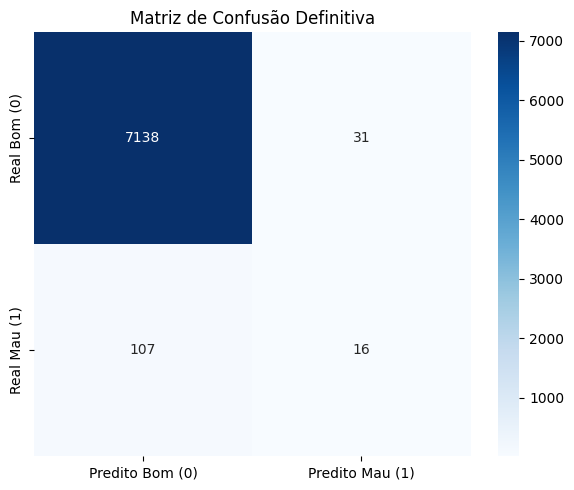

In [9]:
# Gráfico da Matriz de Confusão
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predito Bom (0)', 'Predito Mau (1)'],
            yticklabels=['Real Bom (0)', 'Real Mau (1)'])
plt.title('Matriz de Confusão Definitiva')
plt.tight_layout()
plt.show()

Identificamos na matriz de confusão 7138 verdadeiros bons (clientes que eram realmente bons pagadores e o modelo acertou ao prever que eram bons), 16 verdadeiros maus (clientes que eram realmente maus pagadores e o modelo acertou ao prever que eram maus), 31 falsos maus (clientes que eram bons pagadores, mas o modelo errou colocando-os como "Maus Pagadores") e 16 falsos bons (clientes maus pagadores que o modelo identificou como bons pagadores).

## 4. Importância das variáveis


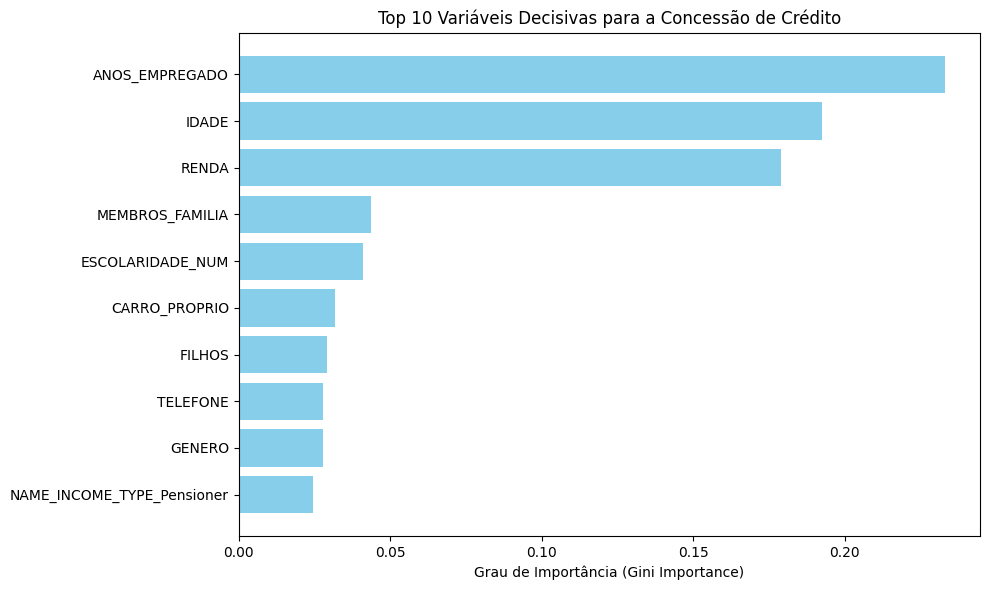

In [8]:
#Gráfico da importância das variáveis
importances = modelo_campeao.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10 variáveis

plt.figure(figsize=(10, 6))
plt.title("Top 10 Variáveis Decisivas para a Concessão de Crédito")
plt.barh(range(len(indices)), importances[indices], align="center", color='skyblue')
plt.yticks(range(len(indices)), [X_test.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel("Grau de Importância (Gini Importance)")
plt.tight_layout()
plt.show()

As variáveis que mais pesam são o tempo empregado, a idade e a renda, fazendo sentido com o mercado.

O tempo de emprego alto demonstra estabilidade, a idade também ajuda na maturidade financeira e a renda influencia diretamente na capacidade de pagamento.

## 5. Implicações práticas

Variáveis como ANOS_EMPREGADO e IDADE surgiram no topo da importância do Random Forest. Isso prova que a estabilidade profissional e a maturidade são os principais escudos contra a inadimplência. Políticas automatizadas baseadas em regras simples de renda devem ser substituídas por este modelo combinatório.

Ao observar os quadrantes da Matriz de Confusão, os Falsos Positivos representam clientes legítimos que foram recusados (custo de oportunidade/perda de receita), enquanto os Falsos Negativos representam perdas patrimoniais diretas (crédito não recuperado). O modelo permite que a diretoria mude o threshold (limiar de aprovação) de forma dinâmica: se o cenário econômico do país for de recessão, a mesa aperta o filtro aumentando o Recall; se for de expansão, afrouxa-se o critério para aprovar mais.

## 6. Limitações

O projeto apresenta limitações técnicas como os dados utilizados (application_record.csv) que são puramente demográficos e estáticos. Eles registram o que o cliente diz ser, mas não refletem o comportamento financeiro em tempo real (como o uso recente de cheque especial, quantidade de consultas recentes ao Serasa/SPC ou o endividamento consolidado no Banco Central - SCR). Possuem ainda alta similaridade levantando a suspeita de possíveis cadastros duplicados.

O histórico de pagamento não discrimina o volume financeiro dos inadimplentes (um atraso de 50 reais na fatura recebeu o mesmo peso de um atraso de 50.000 reais). Essa falta de ponderação pelo saldo devedor limita o modelo a prever a frequência do evento, mas não a severidade do prejuízo financeiro real.